<a href="https://colab.research.google.com/github/student-prince-kumar/powerBI_dashboard_project/blob/main/Gurgaon_Estate_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('data of gurugram real Estate.csv')

In [3]:
display(pd.read_csv('data of gurugram real Estate.csv'))

,Price,Status,Area,Rate per sqft,Property Type,Locality,Builder Name,RERA Approval,BHK_Count,Society,Company Name,Flat Type
0,10700000,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,Approved by RERA,2,M3M Antalya Hills Phase I,M3M,Apartment
1,14400000,Under Construction,1528,"9,450",3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,Approved by RERA,3,M3M Antalya Hills Phase I,M3M,Apartment
2,10700000,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,Approved by RERA,2,M3M Antalya Hills Phase I,M3M,Apartment
3,40000000,Ready to move,4500,"8,888",4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,Not approved by RERA,4,Outside Socity,Outside,Plot
4,24000000,Under Construction,1800,"13,333",3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,Approved by RERA,3,Anant Raj Estate Plots,Anant,Floor
...,...,...,...,...,...,...,...,...,...,...,...,...
19510,24100000,Ready to move,1381,"17,500",2 BHK Apartment in Sobha City,Sector 108,Shree Realstic One,Not approved by RERA,2,Sobha City,Sobha,Apartment
19511,36200000,Ready to move,2072,"17,500",3 BHK Apartment in Sobha City,Sector 108,Shree Realstic One,Not approved by RERA,3,Sobha City,Sobha,Apartment
19512,39100000,Under Construction,2445,"16,002",3 BHK Apartment in Pyramid Alban,Sector 71,Shree Realstic One,Approved by RERA,3,Pyramid Alban,Pyramid,Apartment
19513,37700000,Under Construction,2360,"16,001",3 BHK Apartment in Pyramid Alban,Sector 71,Shree Realstic One,Approved by RERA,3,Pyramid Alban,Pyramid,Apartment


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19515 entries, 0 to 19514
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Price          19515 non-null  object
 1   Status         19515 non-null  object
 2   Area           19515 non-null  int64 
 3   Rate per sqft  19515 non-null  object
 4   Property Type  19515 non-null  object
 5   Locality       19515 non-null  object
 6   Builder Name   19515 non-null  object
 7   RERA Approval  19515 non-null  object
 8   BHK_Count      19515 non-null  int64 
 9   Society        19515 non-null  object
 10  Company Name   19515 non-null  object
 11  Flat Type      19515 non-null  object
dtypes: int64(2), object(10)
memory usage: 1.8+ MB


In [5]:
df.head()

,Price,Status,Area,Rate per sqft,Property Type,Locality,Builder Name,RERA Approval,BHK_Count,Society,Company Name,Flat Type
0,10700000,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,home,Approved by RERA,2,M3M Antalya Hills Phase I,M3M,Apartment
1,14400000,Under Construction,1528,"9,450",3 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,Property In Gurgaon,Approved by RERA,3,M3M Antalya Hills Phase I,M3M,Apartment
2,10700000,Under Construction,1138,"9,450",2 BHK Apartment in M3M Antalya Hills Phase I,Sector 79,properties for sale in Gurgaon,Approved by RERA,2,M3M Antalya Hills Phase I,M3M,Apartment
3,40000000,Ready to move,4500,"8,888",4 BHK Independent Floor,Sector 57,MM India Pvt Ltd,Not approved by RERA,4,Outside Socity,Outside,Plot
4,24000000,Under Construction,1800,"13,333",3 BHK Independent Floor in Anant Raj Estate Plots,Sector 63,MM India Pvt Ltd,Approved by RERA,3,Anant Raj Estate Plots,Anant,Floor


In [6]:
print(df.columns.tolist())

['Price', 'Status', 'Area', 'Rate per sqft', 'Property Type', 'Locality', 'Builder Name', 'RERA Approval', 'BHK_Count', 'Society', 'Company Name', 'Flat Type']


In [7]:
df.shape

(19515, 12)

In [8]:
# Data Cleaning.
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())
df  = df.drop_duplicates()

['price', 'status', 'area', 'rate_per_sqft', 'property_type', 'locality', 'builder_name', 'rera_approval', 'bhk_count', 'society', 'company_name', 'flat_type']


In [9]:
# Numeric Column Cleaning.
df["price"] = df["price"].astype(str).str.replace(",", "").astype(int)
df["area"] = df["area"].astype(str).str.replace(",", "").astype(int)
df["rate_per_sqft"] = df["rate_per_sqft"].astype(str).str.replace(",", "").astype(int)
print(df['rate_per_sqft'])

0         9450
1         9450
2         9450
3         8888
4        13333
         ...  
19510    17500
19511    17500
19512    16002
19513    16001
19514    16005
Name: rate_per_sqft, Length: 14223, dtype: int64


In [10]:
# Categorical column cleaning.
df["status"] = df["status"].str.strip().str.lower()

# Only apply rera_approval transformation if it's currently an object (string) type
if df['rera_approval'].dtype == 'object':
    df["rera_approval"] = df["rera_approval"].str.strip().str.lower().map({"approved by rera": True, "not approved by rera": False})

df["flat_type"] = df["flat_type"].str.strip().str.lower()
print(df)

          price              status  area  rate_per_sqft  \
0      10700000  under construction  1138           9450   
1      14400000  under construction  1528           9450   
2      10700000  under construction  1138           9450   
3      40000000       ready to move  4500           8888   
4      24000000  under construction  1800          13333   
...         ...                 ...   ...            ...   
19510  24100000       ready to move  1381          17500   
19511  36200000       ready to move  2072          17500   
19512  39100000  under construction  2445          16002   
19513  37700000  under construction  2360          16001   
19514  36500000  under construction  2282          16005   

                                           property_type    locality  \
0           2 BHK Apartment in M3M Antalya Hills Phase I   Sector 79   
1           3 BHK Apartment in M3M Antalya Hills Phase I   Sector 79   
2           2 BHK Apartment in M3M Antalya Hills Phase I   Sect

In [11]:
# 1. Which is the costliest flat in the dataset?
costliest_flat = df.loc[df["price"].idxmax()]
print(costliest_flat)



price                                  1226300000
status                              ready to move
area                                        16500
rate_per_sqft                               74323
property_type    6 BHK Apartment in DLF Camellias
locality                                Sector 42
builder_name                    Provident Capital
rera_approval                               False
bhk_count                                       6
society                             DLF Camellias
company_name                                  DLF
flat_type                               apartment
Name: 2839, dtype: object


In [12]:
print(f"costliest flat is a {costliest_flat['bhk_count']} bhk flat located in {costliest_flat['locality']} price at {costliest_flat['price']/10000000} crores in A{costliest_flat['society']} society.")

costliest flat is a 6 bhk flat located in Sector 42 price at 122.63 crores in A DLF Camellias society.


In [13]:
# 2. Which locality has the highest average price?
highest_avg_price_by_locality= df.groupby("locality")["price"].mean().idxmax()
display(f"The locality with the highest average price is {highest_avg_price_by_locality}")
display(df.groupby("locality")["price"].mean().sort_values(ascending=False).head(20))

'The locality with the highest average price is Baliawas'

,price
locality,
Baliawas,5.833333e+08
Sector 42,5.023612e+08
Beverly Park,1.953667e+08
Aralias Drive,1.636583e+08
Golf Course Road,1.475139e+08
Sector 73,1.281941e+08
37D Dwarka Exp Gurgaon,1.197000e+08
Ambience Island,1.100000e+08
Sector 24,1.086423e+08


In [14]:
# 3. Which locality has the highest rate per square foot?.
highest_rate_per_sqft_by_locality = df.groupby("locality")["rate_per_sqft"].mean().idxmax()
display(f"The locality with highest rate per square fit is {highest_rate_per_sqft_by_locality}")
display(df.groupby("locality")["price"].mean().sort_values(ascending=False).head(20))

'The locality with highest rate per square fit is Sector 42'

,price
locality,
Baliawas,5.833333e+08
Sector 42,5.023612e+08
Beverly Park,1.953667e+08
Aralias Drive,1.636583e+08
Golf Course Road,1.475139e+08
Sector 73,1.281941e+08
37D Dwarka Exp Gurgaon,1.197000e+08
Ambience Island,1.100000e+08
Sector 24,1.086423e+08


In [15]:

# 4. Do ready-to-move properties cost more than under-construction properties?.
ready_to_move_avg_price = df[df["status"] == "ready to move"]["price"].mean()
under_construction_avg_price = df[df["status"] == "under construction"]["price"].mean()

if ready_to_move_avg_price > under_construction_avg_price:
  print("Ready-to-move properties cost more than under-construction properties.")
else:
  print("Under-construction properties cost more than ready-to-move properties.")

Ready-to-move properties cost more than under-construction properties.


In [16]:
# 5. Do RERA-approved properties command a price premium?.
rera_approved_avg_price = df[df["rera_approval"] == True]["price"].mean()
rera_not_approved_avg_price = df[df["rera_approval"] == False]["price"].mean()

if rera_approved_avg_price > rera_not_approved_avg_price:
  print("RERA approved properties command a price premium.")
else:
  print("RERA approved properties do not command a price premium.")

RERA approved properties do not command a price premium.


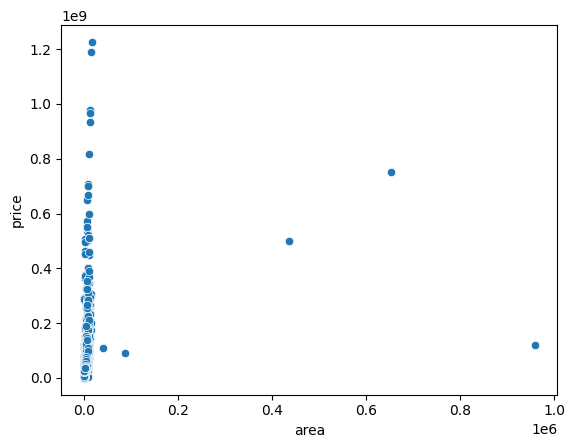

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
# 6. How does area (sqft) impact property price?
sns.scatterplot(x = "area", y = "price", data  = df)
plt.show()

In [18]:
# 7. Which BHK configuration is the most expensive on average?
most_expensive_bhk_config = df.groupby("bhk_count")["price"].mean().idxmax()
print(f"The most expensive BKH configuration on average is {most_expensive_bhk_config}")

The most expensive BKH configuration on average is 7


In [19]:
# 8. Which property type (Apartment, Floor, Plot) is the costliest?
costliest_flat_type = df.groupby("flat_type")["price"].mean().idxmax()
costliest_property_type = df.groupby("property_type")["price"].mean().idxmax()
print(f"The costliest flat type is {costliest_flat_type}")
print(f"The costliest property type is {costliest_property_type}")

The costliest flat type is penthouse
The costliest property type is 6 BHK Apartment in DLF Camellias


In [20]:
# 9. Do certain builders or companies consistently price higher?
print("The top 5 buiders with the highest price are: ", end = " ")
top_5_builders = df.groupby("company_name")["rate_per_sqft"].mean().sort_values(ascending=False).head(5)
for builder in top_5_builders.index:
    print(builder, end = ", ")

The top 5 buiders with the highest price are:  Camelliaass, Cameliaas, Tulip, Prom, Magnoliaass, 

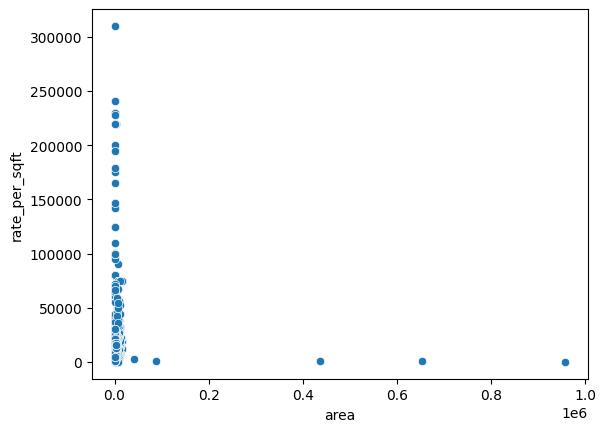

In [21]:
# 10. Are larger homes always more expensive per square foot? show in bar chat.
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x = "area", y = "rate_per_sqft", data = df)
plt.show()

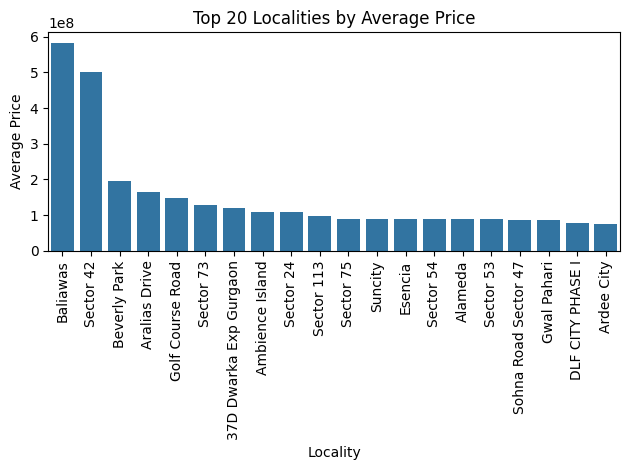

In [22]:
#11. create a bar chat Which Locality has the highest average Price?
import matplotlib.pyplot as plt
import seaborn as sns

avg_price_by_locality = df.groupby('locality')['price'].mean().sort_values(ascending=False).head(20)
sns.barplot(x=avg_price_by_locality.index, y=avg_price_by_locality.values)
plt.xticks(rotation=90)
plt.xlabel('Locality')
plt.ylabel('Average Price')
plt.title('Top 20 Localities by Average Price')
plt.tight_layout()
plt.show()

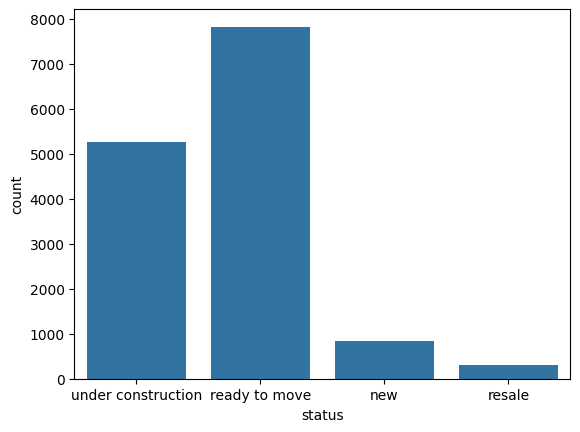

In [23]:
#12. Using count plot show that:
# How many properties are:Under Construction vs Ready to move?

import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x = "status", data = df)
plt.show()

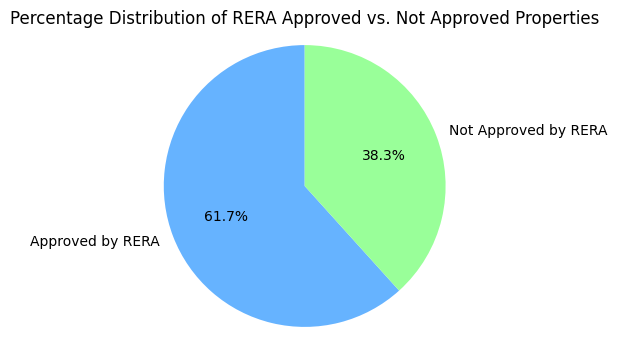

In [24]:
#13.What is the percentage distribution of RERA Approved vs Not Approved properties? describe in piechart.
import matplotlib.pyplot as plt

rera_counts = df['rera_approval'].value_counts()

# Calculate percentages
percentage_rera = rera_counts / rera_counts.sum() * 100

# Plotting the pie chart
plt.figure(figsize=(4, 4))
plt.pie(percentage_rera, labels=['Approved by RERA', 'Not Approved by RERA'], autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#99ff99'])
plt.title('Percentage Distribution of RERA Approved vs. Not Approved Properties')
plt.axis('equal')
plt.show()

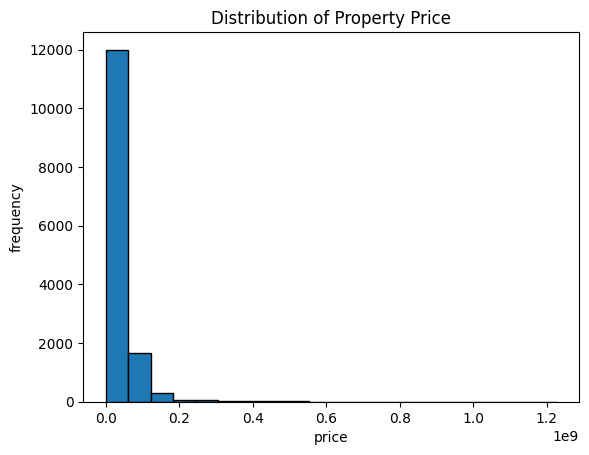

In [25]:
#Histogram
#14.What is the distribution of Property Prices?
import matplotlib.pyplot as plt
import seaborn as sns
plt.hist(df['price'], bins = 20 , edgecolor = "black")
plt.xlabel("price")
plt.ylabel("frequency")
plt.title("Distribution of Property Price")
plt.show()

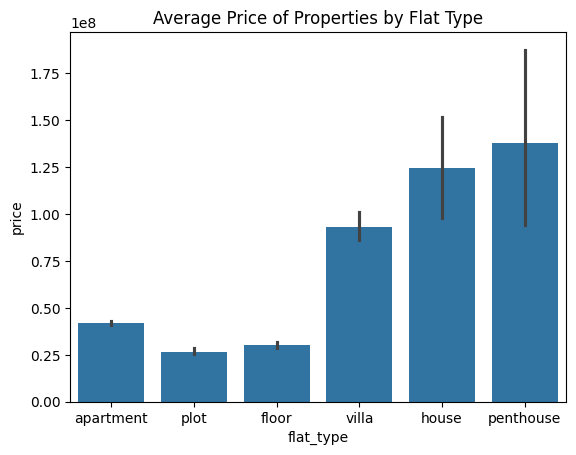

In [26]:
#15. Compare average price of properties by Flat Type. using Bar Chart (Grouped)
import matplotlib.pyplot as plt
import seaborn as sns
avg_price_by_flat_type = df.groupby("flat_type")['price'].mean().head()
sns.barplot(x = "flat_type", y = "price", data = df)
plt.xlabel("flat_type")
plt.ylabel("price")
plt.title("Average Price of Properties by Flat Type")
plt.show()

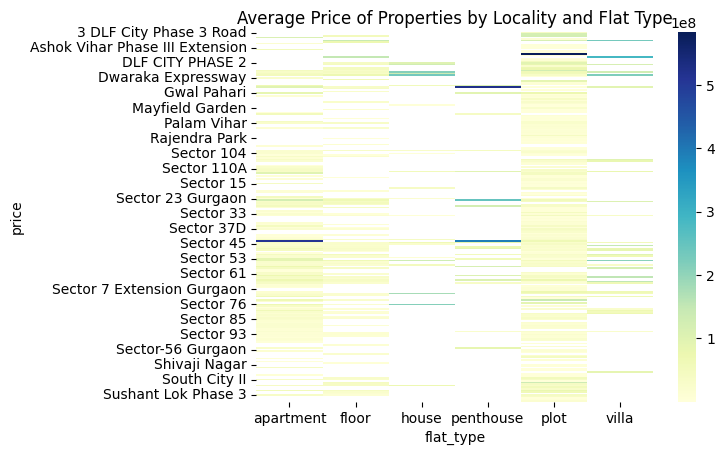

In [27]:
#16.Show relationship between:  Locality vs Flat Type → Average Price using HEATMAP.
import matplotlib.pyplot as plt
import seaborn as sns
avg_price_by_locality_and_flat_type = df.groupby(['locality', 'flat_type'])['price'].mean().unstack()
sns.heatmap(avg_price_by_locality_and_flat_type, cmap = 'YlGnBu')
plt.xlabel("flat_type")
plt.ylabel("price")
plt.title("Average Price of Properties by Locality and Flat Type")
plt.show()

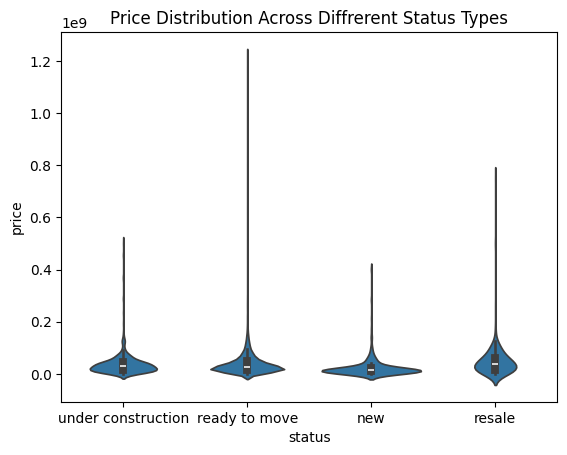

In [28]:
#17. Violin Plot
# Question: Compare price distribution across different Status types.
import matplotlib.pyplot as plt
import seaborn as sns
sns.violinplot(x = "status", y = "price", data = df)
plt.xlabel("status")
plt.ylabel("price")
plt.title("Price Distribution Across Diffrerent Status Types")
plt.show()

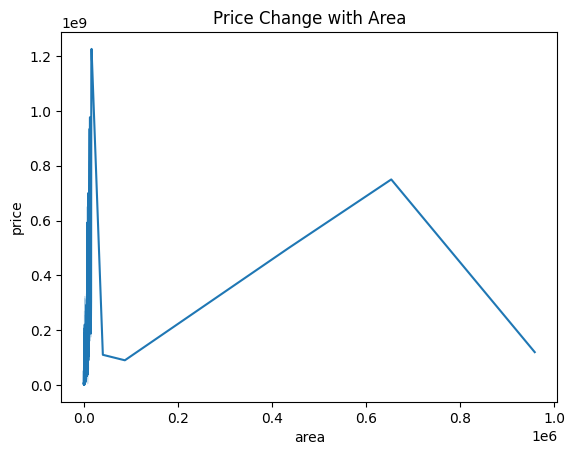

In [29]:
#18. Line Plot
# Question: If you sort data by Area, how does Price change with Area?
import matplotlib.pyplot as plt
import seaborn as sns
df_sorted = df.sort_values(by = "area")
sns.lineplot(x = "area", y = "price", data  = df_sorted)
plt.xlabel("area")
plt.ylabel("price")
plt.title("Price Change with Area")
plt.show()

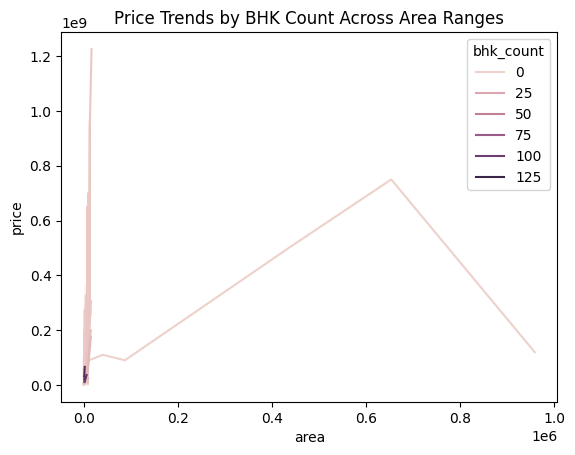

In [30]:
#19.Multi-Line Chart
# Question: Compare Price trends by BHK_Count across Area ranges. X → Area , Y → Price , Hue → BHK_Count
import matplotlib.pyplot as plt
import seaborn as sns
sns.lineplot(x = "area", y = "price", hue = "bhk_count", data = df)
plt.xlabel("area")
plt.ylabel("price")
plt.title("Price Trends by BHK Count Across Area Ranges")
plt.show()

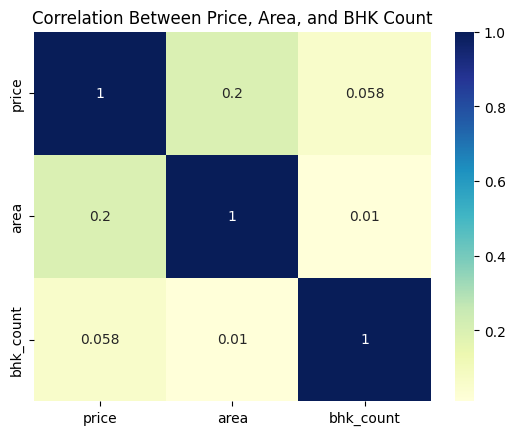

In [31]:
#20. Find correlation between: Price, Area, BHK_Count
# Insight: Which factor impacts price most?
import matplotlib.pyplot as plt
import seaborn as sns
correlation_matrix = df[["price", "area", "bhk_count"]].corr()
sns.heatmap(correlation_matrix , annot = True, cmap = "YlGnBu")
plt.title("Correlation Between Price, Area, and BHK Count")
plt.show()

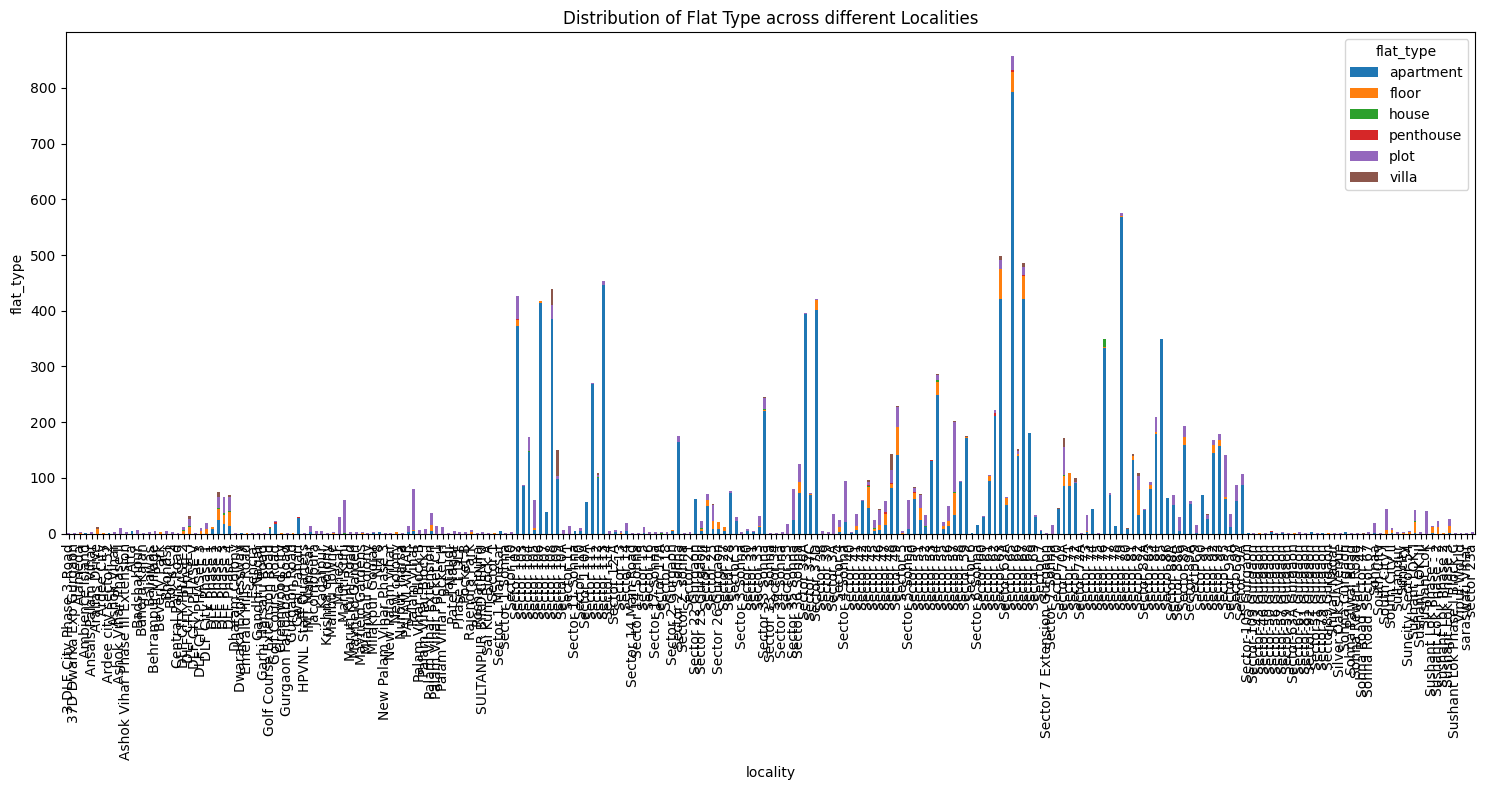

In [32]:
#21. Stacked Bar Chart
# Question: Distribution of Flat Type across different Localities.
import matplotlib.pyplot as plt
import seaborn as sns
# Ensure column names are in lowercase and replace spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
flat_type_by_locality = df.groupby("locality")["flat_type"].value_counts().unstack()

fig, ax = plt.subplots(figsize=(15, 8)) # Create figure and axes
flat_type_by_locality.plot(kind = "bar", stacked = True, ax=ax) # Pass the axes to the plot method

plt.xlabel("locality")
plt.ylabel("flat_type")
plt.title("Distribution of Flat Type across different Localities")
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()